# Phase 3 — Price Elasticity & Promotion Effect Estimation

Phase 2 established two things that shape the model here:

1. Price and promotion co-move (especially for Eggs), so a naive
   price-on-quantity regression will confuse the two effects.
2. For Bath Tissues specifically, the *product mix* that gets promoted
   differs from the mix that doesn't — a category-level model would
   attribute the wrong sign to promotion. Product-level fixed effects are
   required.

**Model spec:**

```
log(quantity) ~ log(price) + is_displayed + is_mailed
                + product fixed effects + store fixed effects + week fixed effects
```

This is a standard log-log demand model with three-way additive fixed
effects. Product FE absorb each SKU's own baseline demand level (fixing
the Bath Tissues composition problem). Store FE absorb store-specific
demand/traffic levels. Week FE absorb any common shock that hits all
products in a given week (a holiday, a competitor's move, etc.) — this is
what lets `is_displayed`/`is_mailed` be interpreted as the promotion's
effect net of whatever else was happening that week.

The coefficient on `log(price)` is directly interpretable as the price
elasticity of demand, because this is a log-log (constant elasticity)
specification.

In [1]:
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110

con = duckdb.connect('../warehouse.duckdb', read_only=True)

## 1. Build the product × store × week panel

Transactions are aggregated to product-store-week (summing quantity, and
computing unit price as total revenue / total quantity, i.e. a
quantity-weighted average price for that week). This is then left-joined
to the promotions table, same as Phase 2.

**A limitation worth stating plainly:** this dataset only contains rows
where at least one unit was sold. There's no way to distinguish "zero
units sold that week" from "product wasn't stocked at that store" — so
this panel is unbalanced, and the model can only speak to how *quantity
sold, given some was sold* responds to price and promotion. It cannot
capture a pure stock-out or an extensive-margin "whether to carry this
product at all" effect. This is a standard limitation of scanner-panel
elasticity work, not specific to this dataset.

In [2]:
query = """
WITH agg AS (
    SELECT t.product_id, t.store_id, t.week, p.product_category, p.brand, p.package_size,
        SUM(t.quantity) AS quantity,
        SUM(t.sales_value) / NULLIF(SUM(t.quantity),0) AS unit_price
    FROM fact_transactions t
    JOIN dim_product p ON t.product_id = p.product_id
    WHERE p.product_category IN ('EGGS', 'BATH TISSUES')
    GROUP BY t.product_id, t.store_id, t.week, p.product_category, p.brand, p.package_size
)
SELECT a.*,
       COALESCE(pr.is_displayed,0) AS is_displayed,
       COALESCE(pr.is_mailed,0) AS is_mailed
FROM agg a
LEFT JOIN fact_promotions pr
  ON a.product_id = pr.product_id AND a.store_id = pr.store_id AND a.week = pr.week
"""
df = con.execute(query).fetchdf()

# drop the handful of zero/null price rows (data artefacts, not real transactions)
before = len(df)
df = df[df.unit_price > 0].dropna(subset=['unit_price','quantity'])
print(f"Dropped {before - len(df)} rows with zero/missing price")

df['log_qty'] = np.log(df['quantity'])
df['log_price'] = np.log(df['unit_price'])

df.groupby('product_category').agg(
    n_products=('product_id','nunique'),
    n_stores=('store_id','nunique'),
    n_obs=('quantity','count')
)

Dropped 1 rows with zero/missing price


,n_products,n_stores,n_obs
product_category,,,
BATH TISSUES,121,155,7248
EGGS,91,207,11534


## 2. Naive model — no fixed effects

This is what you'd get from a quick `quantity ~ price` regression without
thinking about the confound. Reported here specifically to be compared
against the corrected model below, not as a result to trust on its own.

In [3]:
naive_results = {}
for cat in ['EGGS','BATH TISSUES']:
    sub = df[df.product_category==cat]
    m = smf.ols('log_qty ~ log_price + is_displayed + is_mailed', data=sub).fit(
        cov_type='cluster', cov_kwds={'groups': sub['product_id']})
    naive_results[cat] = m
    print(f"--- {cat} (naive) ---")
    print(f"elasticity: {m.params['log_price']:.3f}  (se {m.bse['log_price']:.3f}, p={m.pvalues['log_price']:.4f})")
    print(f"R²: {m.rsquared:.3f}")
    print()

--- EGGS (naive) ---
elasticity: -0.200  (se 0.067, p=0.0028)
R²: 0.155

--- BATH TISSUES (naive) ---
elasticity: -0.207  (se 0.035, p=0.0000)
R²: 0.199



## 3. Fixed-effects model — the corrected estimate

Same data, same dependent variable, now absorbing product, store, and week
fixed effects. Standard errors are clustered by product to allow for
correlated errors within the same product across stores/weeks (a
conservative choice — arguably two-way clustering by product *and* week
would be even safer, and is a reasonable next refinement rather than a
concern that invalidates this result).

In [4]:
fe_results = {}
for cat in ['EGGS','BATH TISSUES']:
    sub = df[df.product_category==cat]
    m = smf.ols(
        'log_qty ~ log_price + is_displayed + is_mailed + C(product_id) + C(store_id) + C(week)',
        data=sub
    ).fit(cov_type='cluster', cov_kwds={'groups': sub['product_id']})
    fe_results[cat] = m
    print(f"--- {cat} (fixed effects) ---")
    print(f"elasticity: {m.params['log_price']:.3f}  (se {m.bse['log_price']:.3f}, p={m.pvalues['log_price']:.4f})")
    print(f"is_displayed: {m.params['is_displayed']:.3f}  (p={m.pvalues['is_displayed']:.4f})")
    print(f"is_mailed: {m.params['is_mailed']:.3f}  (p={m.pvalues['is_mailed']:.4f})")
    print(f"R²: {m.rsquared:.3f}  |  parameters: {len(m.params)}  |  n: {int(m.nobs)}")
    print()

--- EGGS (fixed effects) ---
elasticity: -0.519  (se 0.058, p=0.0000)
is_displayed: 0.097  (p=0.0000)
is_mailed: 0.254  (p=0.0000)
R²: 0.268  |  parameters: 352  |  n: 11534



--- BATH TISSUES (fixed effects) ---
elasticity: -0.194  (se 0.038, p=0.0000)
is_displayed: 0.031  (p=0.1302)
is_mailed: 0.032  (p=0.0027)
R²: 0.294  |  parameters: 330  |  n: 7248



## 4. Naive vs. corrected — visualizing the bias

This is the direct payoff of the Phase 2 confound analysis: how much did
ignoring the price-promotion confound actually distort the elasticity
estimate?

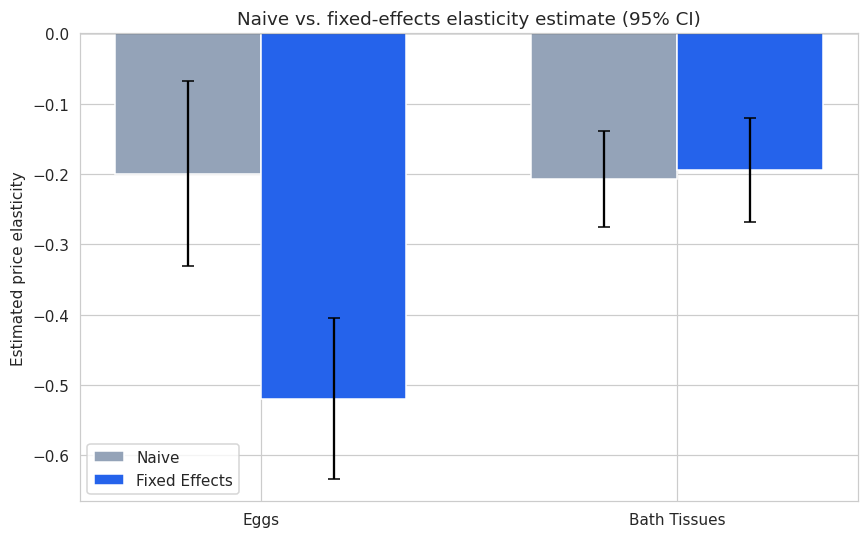

In [5]:
compare = pd.DataFrame({
    'category': ['Eggs','Eggs','Bath Tissues','Bath Tissues'],
    'model': ['Naive','Fixed Effects','Naive','Fixed Effects'],
    'elasticity': [
        naive_results['EGGS'].params['log_price'], fe_results['EGGS'].params['log_price'],
        naive_results['BATH TISSUES'].params['log_price'], fe_results['BATH TISSUES'].params['log_price']
    ],
    'se': [
        naive_results['EGGS'].bse['log_price'], fe_results['EGGS'].bse['log_price'],
        naive_results['BATH TISSUES'].bse['log_price'], fe_results['BATH TISSUES'].bse['log_price']
    ]
})

fig, ax = plt.subplots(figsize=(8,5))
x = np.arange(2)
width = 0.35
for i, model in enumerate(['Naive','Fixed Effects']):
    sub = compare[compare.model==model]
    color = '#94a3b8' if model=='Naive' else '#2563eb'
    ax.bar(x + i*width, sub.elasticity, width, yerr=1.96*sub.se, capsize=4,
           label=model, color=color)
ax.set_xticks(x + width/2)
ax.set_xticklabels(['Eggs','Bath Tissues'])
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Estimated price elasticity')
ax.set_title('Naive vs. fixed-effects elasticity estimate (95% CI)')
ax.legend()
plt.tight_layout()
plt.savefig('figures/06_naive_vs_fe_elasticity.png', bbox_inches='tight')
plt.show()

**Reading this:** for **Eggs**, the naive model understates price
sensitivity by more than half (-0.20 vs. the corrected -0.52) — ignoring
the confound would have led to a materially wrong business conclusion
about how price-sensitive shoppers actually are for this product. For
**Bath Tissues**, the two estimates are close (-0.21 vs. -0.19), consistent
with what Phase 2 found: promotion there wasn't really co-moving with
price in a simple way, it was a product-mix effect instead, so the naive
price coefficient wasn't as badly contaminated to begin with. This is a
good concrete demonstration of why the fixed-effects correction matters
for one category and matters less for another — it's not a fixed "20%
correction factor," it depends on how the confound actually operates in
that category.

Both corrected elasticities are between 0 and -1 (inelastic): a 1% price
increase reduces quantity by less than 1%, which fits both categories
being everyday staples with limited substitutes on a given shopping trip.

## 5. Promotion effects, in plain percentage terms

The `is_displayed`/`is_mailed` coefficients are log points; converting via
$e^\beta - 1$ gives the percentage change in quantity attributable to that
promotion type, holding price and all fixed effects constant.

In [6]:
promo_summary = []
for cat in ['EGGS','BATH TISSUES']:
    m = fe_results[cat]
    for var, label in [('is_displayed','In-store display'), ('is_mailed','Mailer/flyer feature')]:
        pct_effect = (np.exp(m.params[var]) - 1) * 100
        promo_summary.append({
            'category': cat.title(),
            'promo_type': label,
            'pct_lift': round(pct_effect,1),
            'p_value': round(m.pvalues[var],4),
            'significant': m.pvalues[var] < 0.05
        })
promo_df = pd.DataFrame(promo_summary)
promo_df

,category,promo_type,pct_lift,p_value,significant
0,Eggs,In-store display,10.2,0.0000,True
1,Eggs,Mailer/flyer feature,28.9,0.0000,True
2,Bath Tissues,In-store display,3.2,0.1302,False
3,Bath Tissues,Mailer/flyer feature,3.3,0.0027,True


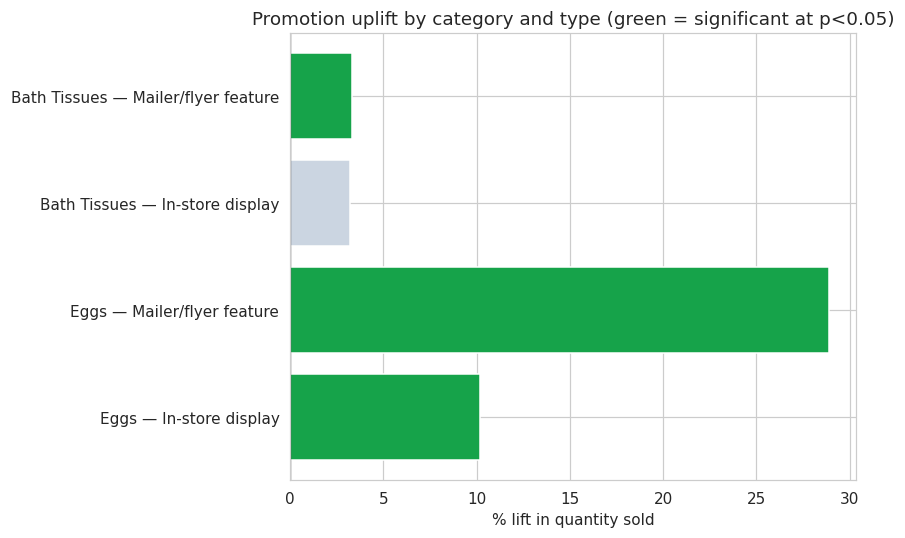

In [7]:
fig, ax = plt.subplots(figsize=(8,5))
colors = promo_df['significant'].map({True:'#16a34a', False:'#cbd5e1'})
bars = ax.barh(promo_df['category'] + ' — ' + promo_df['promo_type'], promo_df['pct_lift'], color=colors)
ax.set_xlabel('% lift in quantity sold')
ax.set_title('Promotion uplift by category and type (green = significant at p<0.05)')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('figures/07_promo_uplift_pct.png', bbox_inches='tight')
plt.show()

**Reading this:** for **Eggs**, both promo types genuinely move volume —
mailer features especially (+28.9%), with in-store display adding a
further +10.2%. For **Bath Tissues**, the effect is much smaller and
in-store display isn't statistically significant (p=0.13) — consistent
with a category where purchases are more habitual/stockpiled and less
driven by in-the-moment promotion. This is a real, actionable difference:
a mailer budget aimed at Eggs is likely to move volume; the same budget
aimed at Bath Tissue displays is not well supported by this data.

## 6. Does one elasticity number make sense for every SKU?

The pooled model above assumes every product in a category shares the
same price elasticity — reasonable as a category-level summary, but worth
checking. Fitting price elasticity separately for the highest-volume
individual products shows the range of plausible values and, just as
importantly, how much statistical power is lost by not pooling.

In [8]:
def product_elasticity(sub_df, min_obs=200):
    rows = []
    top_products = sub_df.groupby('product_id')['quantity'].sum().sort_values(ascending=False).head(6).index
    for pid in top_products:
        psub = sub_df[sub_df.product_id==pid]
        if len(psub) < min_obs or psub.log_price.std() < 0.01:
            continue
        m = smf.ols('log_qty ~ log_price + is_displayed + is_mailed + C(store_id) + C(week)',
                     data=psub).fit(cov_type='HC1')
        rows.append({
            'product_id': pid, 'brand': psub.brand.iloc[0], 'package_size': psub.package_size.iloc[0],
            'n_obs': len(psub), 'elasticity': round(m.params['log_price'],3),
            'p_value': round(m.pvalues['log_price'],4)
        })
    return pd.DataFrame(rows)

for cat in ['EGGS','BATH TISSUES']:
    print(f"--- {cat}: top products by volume ---")
    display(product_elasticity(df[df.product_category==cat]))
    print()

--- EGGS: top products by volume ---


,product_id,brand,package_size,n_obs,elasticity,p_value
0,981760,Private,1 DZ,3053,-0.183,0.2068
1,840361,Private,1 DZ,2180,-0.112,0.4251
2,994928,Private,1 DZ,1488,-0.378,0.0008
3,923746,Private,18 CT,1703,-0.420,0.0103
4,861272,Private,6 CT,619,0.121,0.5087
5,821083,Private,1 DOZ,452,1.079,0.3199



--- BATH TISSUES: top products by volume ---


,product_id,brand,package_size,n_obs,elasticity,p_value
0,1065593,National,83.5 SQ FT,1452,-0.440,0.4463
1,1123792,Private,110 SQ FT,447,-0.987,0.1310
2,9420312,Private,148.5 SQ FT,322,-0.564,0.1819
3,1075214,National,430.8 SQ FT,325,-0.757,0.2029
4,1070272,National,250.5 SQ FT,297,0.133,0.6801
5,10149640,National,NaN,289,-1.545,0.0005


**Reading this:** individual product elasticities range fairly widely
(roughly -1.5 to +0.1 across the products checked), but almost none of
them are individually statistically significant — sample sizes per
product (hundreds of observations, spread across ~100+ stores and 53
weeks) just aren't large enough for precise product-level estimates. This
is exactly why the pooled model in Section 3 is the right primary result:
pooling with product fixed effects borrows statistical power across
products while still letting each one have its own baseline demand level.
The per-product table here is best read as "the pooled elasticity is a
reasonable average, and individual SKUs plausibly vary around it," not as
a set of six separate reliable estimates.

## 7. Summary and handoff to Phase 4

| Category | Naive elasticity | Corrected elasticity | Display lift | Mailer lift |
|---|---|---|---|---|
| Eggs | -0.20 | **-0.52** | +10.2%* | +28.9%* |
| Bath Tissues | -0.21 | **-0.19** | +3.1% (n.s.) | +3.3%* |

*statistically significant at p<0.05

**Key takeaways:**

- The price-promotion confound identified in Phase 2 was real and
  economically meaningful for Eggs (elasticity more than doubled after
  correction) but not for Bath Tissues — confirming that a single
  "correction factor" doesn't generalise across categories, and this kind
  of category-by-category diagnosis is necessary rather than optional.
- Both categories are price-inelastic, consistent with staple grocery
  goods purchased on a routine basis.
- Promotion effectiveness differs sharply by category: Eggs responds
  strongly to both display and mailer promotion; Bath Tissues barely
  responds to display at all.
- Product-level heterogeneity exists but isn't reliably estimable at the
  individual-SKU level with this sample size — the category-pooled
  estimate (with product fixed effects) is the right level of
  aggregation to report and act on.

**What Phase 4 adds beyond this:** the `is_displayed`/`is_mailed`
coefficients here already give a fixed-effects causal estimate of average
promotion uplift. Phase 4 will go a layer deeper — checking whether the
uplift itself varies systematically (by household income segment, by
store, by how deep the price cut is during the promotion) using
heterogeneous treatment effect methods, which is what actually informs
*which* products/stores to target with a limited promo budget rather than
just confirming that promotion works on average.